
# Mathematical Foundations of Triadic Closure and Recursive Computational Ontologies
## Companion teaching notebook

This notebook is a runnable companion to the paper:

**_Mathematical Foundations of Triadic Closure and Recursive Computational Ontologies:  
A Critical Analysis of the Kosmoplex and Nexus Frameworks_**

It is designed to do four things:

1. restate the paper's core claims in executable form,
2. separate structural claims from conjectural overlays,
3. provide compact mathematical demonstrations and plots,
4. give a reusable notebook scaffold for future papers in this branch.

### Notebook map

- Triadic closure and pairwise insufficiency
- Boundary closure as a universal base class
- First braid and rotating closure
- Fano / 42 glyphs / 168 monads bookkeeping
- OBMT-derived quantities discussed in the paper
- Mark 1 attractor $H=\pi/9$
- Why the 33 Hz branch is not on the same proof footing
- Helix geometry as a scaling implementation
- Final synthesis


In [1]:

# Optional install cell for fresh environments
# %pip install numpy pandas matplotlib


In [2]:

import math
from dataclasses import dataclass
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

PI = math.pi



## 1. Core triad

The paper defines three load-bearing functional roles:

$$
\mathcal{B} = \text{Binding},\qquad
\mathcal{T} = \text{Transformation},\qquad
\mathcal{R} = \text{Relational Readout}.
$$

Working physical map used by the paper:

$$
\mathcal{B} \sim \text{Strong},\qquad
\mathcal{T} \sim \text{Weak},\qquad
\mathcal{R} \sim \text{Electromagnetic}.
$$

The core theorem-shape is:

$$
\mathcal{B}\wedge\mathcal{T}\wedge\mathcal{R}
\Rightarrow
\text{stable-transforming-readable reality.}
$$

The first executable step is to encode the pairwise failure modes.


In [3]:

pairwise_failures = pd.DataFrame(
    [
        ("B ∧ T", "R missing", "Structural Blindness",
         "Bound and transforming substrate exists, but no long-range legibility, chemistry, or observer-compatible exchange."),
        ("B ∧ R", "T missing", "Static Crystalline Death",
         "Stable and readable substrate exists, but no asymmetry, no developmental unfolding, no element ladder."),
        ("T ∧ R", "B missing", "Incoherent Flux",
         "Interaction and change exist, but no durable substrate or confinement; state disperses before persistence."),
    ],
    columns=["Present pair", "Missing role", "Failure mode", "Interpretation"],
)
pairwise_failures


,Present pair,Missing role,Failure mode,Interpretation
0,B ∧ T,R missing,Structural Blindness,"Bound and transforming substrate exists, but n..."
1,B ∧ R,T missing,Static Crystalline Death,"Stable and readable substrate exists, but no a..."
2,T ∧ R,B missing,Incoherent Flux,"Interaction and change exist, but no durable s..."



This is the paper's minimum viability argument in a single table.  
The ontology is not additive. It is closure-constrained.


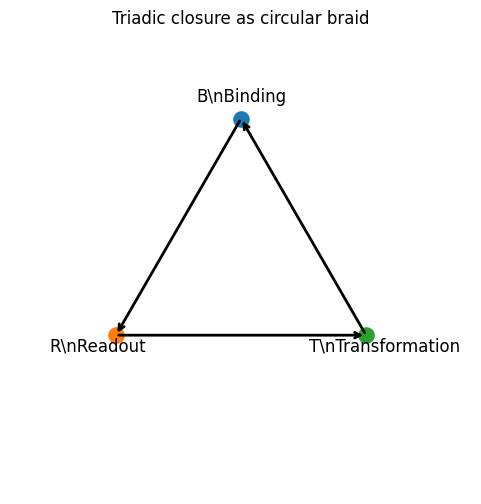

In [4]:

# Visualize the circular braid B -> R -> T -> B used in the paper's closure narrative
fig, ax = plt.subplots(figsize=(6, 6))

angles = np.deg2rad([90, 210, 330])
labels = ["B\\nBinding", "R\\nReadout", "T\\nTransformation"]
xy = np.c_[np.cos(angles), np.sin(angles)]

for (x, y), lab in zip(xy, labels):
    ax.scatter(x, y, s=120)
    ax.text(x * 1.15, y * 1.15, lab, ha="center", va="center", fontsize=12)

order = [0, 1, 2, 0]
for i in range(len(order)-1):
    x1, y1 = xy[order[i]]
    x2, y2 = xy[order[i+1]]
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2),
    )

ax.set_title("Triadic closure as circular braid")
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
ax.axis("off")
plt.show()



## 2. Universal boundary closure law

The later refinement in this branch sharpens the ontology to:

$$
\forall S,\quad
S \models (\mathcal{B},\mathcal{T},\mathcal{R}) \text{ across } \Gamma_S
$$

where $\Gamma_S$ is **not a gap**, but the local interface where the field becomes readable.

This notebook treats that as an abstract base class, then instantiates it across domains.


In [5]:

class ExistenceABC(ABC):
    @abstractmethod
    def bind(self):
        pass

    @abstractmethod
    def transform(self):
        pass

    @abstractmethod
    def read(self):
        pass


@dataclass
class PhysicsClosure(ExistenceABC):
    state: str = "localized"

    def bind(self):
        return "confinement / persistence"

    def transform(self):
        return "interaction / state change"

    def read(self):
        return "radiative / relational legibility"


@dataclass
class BiologyClosure(ExistenceABC):
    state: str = "living"

    def bind(self):
        return "membrane / scaffold / retained form"

    def transform(self):
        return "metabolism / replication / mutation"

    def read(self):
        return "sensing / signaling / expression"


@dataclass
class ComputationClosure(ExistenceABC):
    state: str = "running"

    def bind(self):
        return "state retention"

    def transform(self):
        return "transition rule"

    def read(self):
        return "observable output / residue"


systems = [PhysicsClosure(), BiologyClosure(), ComputationClosure()]

pd.DataFrame(
    {
        "system": [type(s).__name__ for s in systems],
        "B": [s.bind() for s in systems],
        "T": [s.transform() for s in systems],
        "R": [s.read() for s in systems],
    }
)


,system,B,T,R
0,PhysicsClosure,confinement / persistence,interaction / state change,radiative / relational legibility
1,BiologyClosure,membrane / scaffold / retained form,metabolism / replication / mutation,sensing / signaling / expression
2,ComputationClosure,state retention,transition rule,observable output / residue



This does not prove the metaphysics by itself.  
What it does is encode the **inheritance grammar** the paper is aiming at:

$$
S \prec \mathfrak{U},\qquad
\mathfrak{U}=(\mathcal{B},\mathcal{T},\mathcal{R},\Gamma).
$$



## 3. First braid and rotating closure

The supplemental section of the paper introduces the rotating closure:

$$
Q \leftrightarrow C \leftrightarrow O \leftrightarrow Q
$$

with:

- $Q$ = open face / query / need,
- $C$ = constraint face,
- $O$ = solution-object / closed face.

It also formalizes need as exact missing closure:

$$
\Phi_{\mathcal N}:X\to X,\qquad
s=\Phi_{\mathcal N}(s)=\arg\min_{x\in X} E_{\mathcal N}(x).
$$

Below is a toy mismatch field with a unique minimizer.


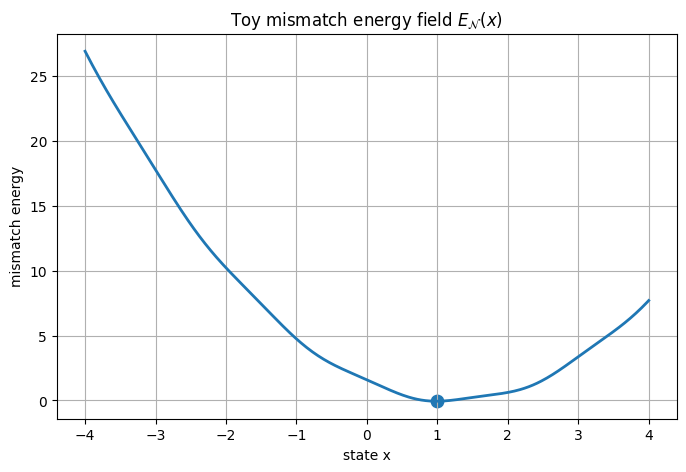

Approximate stable minimizer: x* = 0.9925


In [6]:

# Toy "need field" with a unique stable minimizer
x = np.linspace(-4, 4, 400)
E = (x - 1.2)**2 + 0.15*np.cos(4*x)

x_star = x[np.argmin(E)]
E_star = E.min()

fig, ax = plt.subplots()
ax.plot(x, E, lw=2)
ax.scatter([x_star], [E_star], s=80)
ax.set_title("Toy mismatch energy field $E_\mathcal{N}(x)$")
ax.set_xlabel("state x")
ax.set_ylabel("mismatch energy")
plt.show()

print(f"Approximate stable minimizer: x* = {x_star:.4f}")



This is only an illustration, but it captures the paper's claim that **need deforms the admissible landscape** until stable closure appears as a minimizer rather than as a random pick.



## 4. Fano bookkeeping: 42 glyphs and 168 monads

A major mathematical branch in the paper is the claim that triadic closure unfolds into Fano-plane / octonionic structure, with:

$$
N_{\text{glyphs}} = 7 \times 3 \times 2 = 42
$$

and

$$
N_{\text{monads}} = 42 \times 4 = 168.
$$

The paper also highlights the projection ratio:

$$
\frac{168}{42}=4.
$$


In [7]:

glyphs = 7 * 3 * 2
monads = glyphs * 4
projection_ratio = monads / glyphs

summary = pd.DataFrame(
    {
        "quantity": ["glyphs", "monads", "projection ratio"],
        "value": [glyphs, monads, projection_ratio],
    }
)
summary


,quantity,value
0,glyphs,42.0
1,monads,168.0
2,projection ratio,4.0



This notebook does **not** attempt a full proof of the Fano/OBMT program.  
It records the paper's bookkeeping and turns the main formulas into explicit runnable cells.



## 5. OBMT quantities discussed in the paper

The paper highlights two headline quantities:

### Proton-to-electron mass ratio proposal
$$
\mu = \frac{m_p}{m_e} = 6\pi^5
$$

### Weinberg-angle seed
$$
\sin^2\theta_W = \frac{\sin^2(1)}{\sqrt{3\pi}}
$$

The cells below compute the paper's quoted theoretical values and compare them to the reference values quoted inside the paper itself.


In [8]:

mu_theory = 6 * PI**5
mu_paper_reference = 1836.15267343  # quoted in the paper

sin2_thetaW_theory = math.sin(1)**2 / math.sqrt(3 * PI)
sin2_thetaW_paper_reference = 0.23122  # paper's Z-pole reference scale summary

comparison = pd.DataFrame(
    [
        ("mu = m_p/m_e", mu_theory, mu_paper_reference,
         abs(mu_theory - mu_paper_reference),
         abs(mu_theory - mu_paper_reference)/mu_paper_reference),
        ("sin^2(theta_W)", sin2_thetaW_theory, sin2_thetaW_paper_reference,
         abs(sin2_thetaW_theory - sin2_thetaW_paper_reference),
         abs(sin2_thetaW_theory - sin2_thetaW_paper_reference)/sin2_thetaW_paper_reference),
    ],
    columns=["quantity", "theory", "paper reference", "absolute error", "relative error"],
)
comparison


,quantity,theory,paper reference,absolute error,relative error
0,mu = m_p/m_e,1836.118109,1836.152673,0.034565,0.000019
1,sin^2(theta_W),0.230644,0.231220,0.000576,0.002490



This is the paper's main style of argument in executable form:

- a geometric expression is proposed,
- it yields a dimensionless prediction,
- and the prediction is compared to quoted physical reference values.

Again: this notebook **implements the paper's claims**. It does not independently certify them beyond the algebra shown.



## 6. Mark 1 attractor: $H=\pi/9$

The paper treats

$$
H = \frac{\pi}{9}
$$

as the Mark 1 attractor. It also discusses curvature error when a circular arc is approximated by a chord, using

$$
\epsilon(\theta)=\frac{\theta - 2\sin(\theta/2)}{\theta}
\approx \frac{\theta^2}{24}.
$$

At $\theta=\pi/9$, the paper quotes an error near $0.005$.


In [9]:

def curvature_loss(theta):
    return (theta - 2*math.sin(theta/2)) / theta

H = PI / 9
eps_exact = curvature_loss(H)
eps_taylor = H**2 / 24

pd.DataFrame(
    {
        "quantity": ["H = pi/9", "exact curvature loss", "taylor approximation"],
        "value": [H, eps_exact, eps_taylor],
    }
)


,quantity,value
0,H = pi/9,0.349066
1,exact curvature loss,0.005069
2,taylor approximation,0.005077


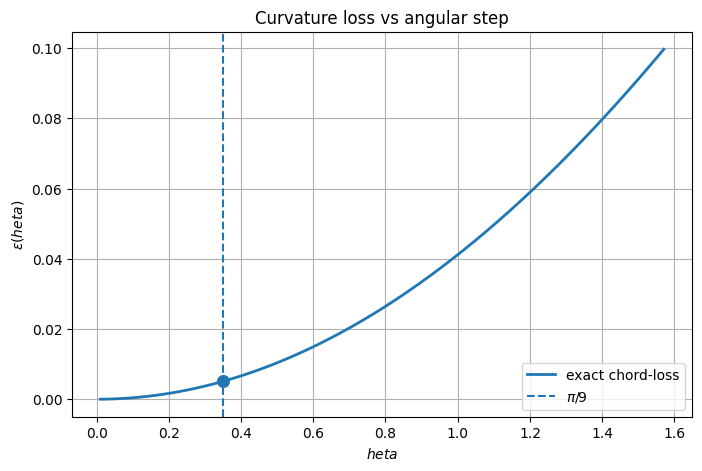

H = pi/9 = 0.34906585
Exact epsilon(H) = 0.00506923
Approx epsilon(H) = 0.00507696


In [10]:

thetas = np.linspace(0.01, np.pi/2, 300)
eps_vals = np.array([curvature_loss(t) for t in thetas])

fig, ax = plt.subplots()
ax.plot(thetas, eps_vals, lw=2, label="exact chord-loss")
ax.axvline(H, linestyle="--", label=r"$\pi/9$")
ax.scatter([H], [eps_exact], s=70)
ax.set_title("Curvature loss vs angular step")
ax.set_xlabel(r"$	heta$")
ax.set_ylabel(r"$\epsilon(	heta)$")
ax.legend()
plt.show()

print(f"H = pi/9 = {H:.8f}")
print(f"Exact epsilon(H) = {eps_exact:.8f}")
print(f"Approx epsilon(H) = {eps_taylor:.8f}")



This section is especially useful pedagogically because it turns one of the paper's central symbolic anchors into a direct numerical demonstration.



## 7. Why the 33 Hz branch is not on the same footing

The paper explicitly separates stronger geometric claims from weaker dimensionful claims.  
A key audit insight is that a frequency stated in hertz is **not** dimensionless. It depends on a time unit.

A notebook should therefore show the difference between:

- a dimensionless geometric quantity such as $\sin^2\theta_W$,
- and a tunable dimensional quantity such as a cycle-per-second output.

The cell below illustrates how easy it is to tune a nominal cycle rate once a base latency is inserted.


In [11]:

# Illustrative only: if a cycle model is f = 1 / (18*tau_base + tau_residual),
# then many observed frequencies can be produced by choosing tau_base/tau_residual.

tau_residual = 0.0
target_frequencies = [31.25, 33.333, 40.0]

rows = []
for f in target_frequencies:
    tau_base = 1 / (18 * f)
    rows.append((f, tau_base))

pd.DataFrame(rows, columns=["target frequency (Hz)", "required tau_base (s)"])


,target frequency (Hz),required tau_base (s)
0,31.250,0.001778
1,33.333,0.001667
2,40.000,0.001389



This is not a disproof of resonance claims.  
It is a notebook reminder that **dimensionful fitting is not the same class of evidence as a zero-parameter dimensionless derivation**.



## 8. Helix as propagation geometry

The paper's helical branch is one of its most visually teachable parts.  
A standard parametrization is:

$$
\mathbf r(t) = (r\cos(\omega t),\; r\sin(\omega t),\; vt).
$$

This notebook draws a simple helix to capture the binding / oscillation / propagation triad:
- radius = binding,
- angular sweep = relational cycling,
- propagation axis = transformation through time.


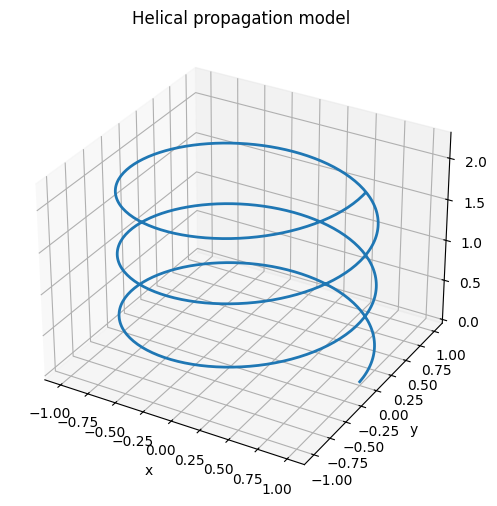

In [12]:

t = np.linspace(0, 6*np.pi, 600)
r = 1.0
omega = 1.0
v = 0.12

x = r*np.cos(omega*t)
y = r*np.sin(omega*t)
z = v*t

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(x, y, z, lw=2)
ax.set_title("Helical propagation model")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()



## 9. DNA as higher-level implementation

The paper and surrounding discussion use DNA not as a loose metaphor, but as a candidate **molecular implementation** of the same closure grammar:

- scaffold / stability,
- replication / transformation,
- sequence legibility / readout.

A compact executable teaching move is to model the double-helix geometry directly.


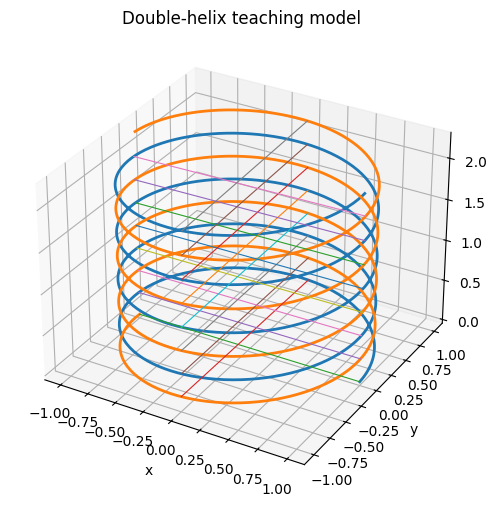

In [13]:

t = np.linspace(0, 8*np.pi, 800)
r = 1.0
pitch = 0.09

x1 = r*np.cos(t)
y1 = r*np.sin(t)
z1 = pitch*t

x2 = r*np.cos(t + np.pi)
y2 = r*np.sin(t + np.pi)
z2 = pitch*t

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(x1, y1, z1, lw=2)
ax.plot(x2, y2, z2, lw=2)

for i in range(0, len(t), 50):
    ax.plot([x1[i], x2[i]], [y1[i], y2[i]], [z1[i], z2[i]], lw=0.8)

ax.set_title("Double-helix teaching model")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()



This does not prove the biochemical thesis by itself.  
What it does do is turn the **helical scaling intuition** into a concrete visual object inside the notebook.



## 10. Observer chain and recursive record

The paper lifts the physical triad into observer architecture:

$$
(I,O,N)
$$

and also summarizes the grammar of existence as:

$$
\text{need} \to \text{space} \to \text{coupling} \to \text{stability} \to \text{memory of difference}.
$$

Below is a tiny toy runtime showing how repeated interaction can accumulate a memory trace.


In [14]:

def toy_observer_runtime(steps=25, stimulus_strength=0.2, damping=0.92):
    memory = 0.0
    history = []
    for k in range(steps):
        stimulus = math.sin(k / 3) * stimulus_strength
        memory = damping * memory + stimulus
        history.append((k, stimulus, memory))
    return pd.DataFrame(history, columns=["step", "stimulus", "memory_trace"])

df_mem = toy_observer_runtime()
df_mem.head()


,step,stimulus,memory_trace
0,0,0.000000,0.000000
1,1,0.065439,0.065439
2,2,0.123674,0.183878
3,3,0.168294,0.337462
4,4,0.194388,0.504852


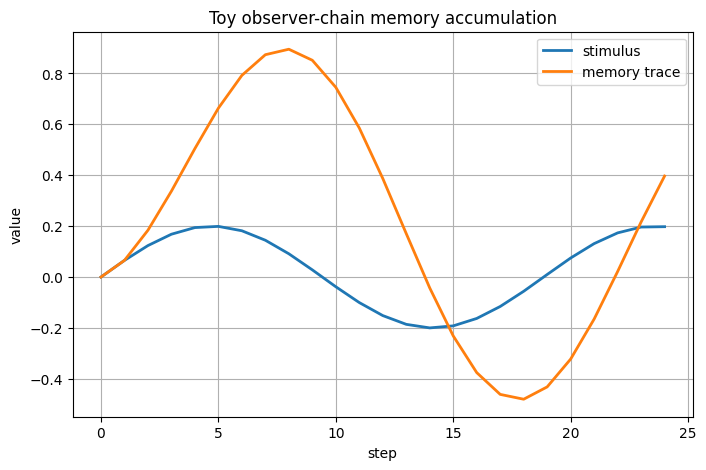

In [15]:

fig, ax = plt.subplots()
ax.plot(df_mem["step"], df_mem["stimulus"], lw=2, label="stimulus")
ax.plot(df_mem["step"], df_mem["memory_trace"], lw=2, label="memory trace")
ax.set_title("Toy observer-chain memory accumulation")
ax.set_xlabel("step")
ax.set_ylabel("value")
ax.legend()
plt.show()



In notebook terms, this gives a concrete hook for the paper's claim that **memory of difference** is the late-stage record left by repeated closure across a boundary.



## 11. Truth ladder for this paper

This notebook is strongest when it does not flatten everything onto one epistemic level.

### Level A — directly executable algebra in the paper
- pairwise insufficiency bookkeeping,
- $6\pi^5$,
- $\sin^2(1)/\sqrt{3\pi}$,
- $H=\pi/9$,
- chord-loss calculation,
- helix parametrization.

### Level B — structural architecture argued by the paper
- B/T/R as universal closure roles,
- observer as recursive triadic lift,
- boundary as interface of legibility,
- universal base-class inheritance view.

### Level C — deeper mathematical substrate proposals
- Fano plane / octonions / 42 glyphs / 168 monads,
- OBMT as source of physical observables,
- particle-spectrum addressing claims.

### Level D — conjectural overlays
- any rigid 33 Hz hardware primitive claim,
- stronger universality claims not yet lifted to a dimensionless proof standard.

That separation is a feature, not a weakness.



## 12. Final compression

The executable teaching form of the paper is:

$$
\mathcal{B}\wedge\mathcal{T}\wedge\mathcal{R}
\Rightarrow
\text{stable-transforming-readable reality}
$$

$$
Q \leftrightarrow C \leftrightarrow O \leftrightarrow Q
$$

$$
\mathfrak{U}=(\mathcal{B},\mathcal{T},\mathcal{R},\Gamma)
$$

$$
S \prec \mathfrak{U}
$$

with the paper's large claim being that reality is not assembled linearly, but rendered through recursive triadic closure.

This notebook does not pretend to finish every proof branch.  
It does provide a runnable mathematical companion for the paper's strongest claims and a clean scaffold for the next milestone notebook.
